# UW / FRF NetCDF Corpus
## Full-dataset loading, EDA, and first-run processing notebook

This notebook is designed for the **real modeling corpus**, not just the original four-file smoke test.  
It can ingest:

- `Sample Data.zip` (the original mixed `stats` + `tri` sample),
- `temp_2.zip` (the additional raw sample files), and
- any **folder of NetCDF files** you point it to when you run it on the full repository.

### What this notebook does
1. discovers and extracts the available NetCDF sources,
2. inventories file families and schema variants,
3. performs first-pass quality checks,
4. generates EDA plots and summary tables,
5. creates standardized processing outputs for downstream modeling.

### Key dataset assumptions reflected here
- The attached Schanta thesis documents the same FUNWAVE-TVD corpus generation workflow: Duck FRF bathymetries, 8-m array spectra, and a large ensemble of roughly 20,000 runs used to model nearshore skewness and asymmetry.
- Two reduced-statistics products exist in the sample (`stats_*`), already standardized to a 200-point representation.
- Two raw-schema variants exist in the sample:
  - **`tri_full`**: raw outputs with undertow and roller variables
  - **`tri_small`**: lighter-weight raw outputs with the core hydrodynamic fields only
- A negative `profileNumber` is **not automatically an error**. In the Duck FRF local coordinate system, one of the frequently surveyed “four lines” is located at `yFRF = -91`, so negative profile numbers can be physically legitimate in this corpus.
- The sample provider explicitly noted a likely typo in `Z_orig`; this notebook therefore treats `Z_wedge` / `Z_interp` as the reliable reduced-profile bathymetry fields for first-pass modeling.

### Processing philosophy
This notebook keeps the **raw time-series branch** and the **reduced-statistics branch** separate.  
That is the safest way to do a first full run before a final supervised shoreline target table is defined.

In [2]:
from pathlib import Path
import json
import math
import os
import re
import shutil
import zipfile
from collections import Counter, defaultdict
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 4)

ROOT = Path.cwd()

# ---- user configuration -----------------------------------------------------
# Leave SOURCE_PATHS empty to auto-discover zip files and NetCDF folders
SOURCE_PATHS = [
]

FORCE_REEXTRACT = False
MAX_FILES = None                
ANALYSIS_Y_INDEX = 1
NORM_GRID_SIZE = 200
RAW_EXAMPLE_COUNT = 3
EXPORT_PROCESSED_TABLES = True
EXPORT_LONG_TABLES = True

WORK_DIR = ROOT / "uw_frf_eda_workspace"
EXTRACT_DIR = WORK_DIR / "extracted"
OUTPUT_DIR = ROOT / "uw_frf_eda_outputs"
FIG_DIR = OUTPUT_DIR / "figures"

WORK_DIR.mkdir(exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"WORK_DIR: {WORK_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

ROOT: C:\Users\adami\USD_assignments\AAI_590
WORK_DIR: C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace
OUTPUT_DIR: C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_outputs


In [3]:
def slugify(text: str) -> str:
    text = re.sub(r"[^A-Za-z0-9]+", "_", str(text)).strip("_")
    return text or "source"

def scalarize(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore")
    if isinstance(value, np.ndarray):
        if value.size == 1:
            return scalarize(value.reshape(-1)[0])
        return [scalarize(v) for v in value.reshape(-1)]
    if isinstance(value, np.generic):
        return value.item()
    return value

def maybe_datetime(value):
    if value in (None, "", "nan"):
        return pd.NaT
    return pd.to_datetime(value, errors="coerce")

def open_ds(path: Path) -> xr.Dataset:
    return xr.open_dataset(path, engine="h5netcdf")

def required_sources(source_paths):
    cleaned = [Path(p) for p in source_paths if Path(p).exists()]
    if cleaned:
        return cleaned

    auto = []
    auto.extend(sorted(ROOT.glob("*.zip")))
    auto.extend(sorted({p.parent for p in ROOT.rglob("*.nc") if OUTPUT_DIR not in p.parents and WORK_DIR not in p.parents}))
    auto = [p for p in auto if p.exists()]
    return auto

def materialize_sources(sources):
    materialized = []
    for src in sources:
        src = Path(src)
        if src.suffix.lower() == ".zip":
            dest = EXTRACT_DIR / slugify(src.stem)
            if FORCE_REEXTRACT and dest.exists():
                shutil.rmtree(dest)
            if not dest.exists():
                print(f"Extracting {src.name} -> {dest}")
                dest.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(src, "r") as zf:
                    zf.extractall(dest)
            materialized.append({"source": src.name, "kind": "zip", "path": dest})
        elif src.is_dir():
            materialized.append({"source": src.name, "kind": "dir", "path": src})
    return materialized

def infer_family_from_vars(var_names):
    var_names = set(var_names)
    if {"Sk_int", "As_int", "Z_interp", "Z_wedge"}.issubset(var_names):
        return "stats"
    if {"eta", "mask", "nubrk", "Z", "U_undertow", "roller"}.issubset(var_names):
        return "tri_full"
    if {"eta", "mask", "nubrk", "Z"}.issubset(var_names):
        return "tri_small"
    return "other_nc"

def summarize_netcdf(path: Path, source_name: str) -> dict:
    with open_ds(path) as ds:
        sizes = {k: int(v) for k, v in ds.sizes.items()}
        vars_ = list(ds.data_vars)
        attrs = {k: scalarize(v) for k, v in ds.attrs.items()}
        family = infer_family_from_vars(vars_)

        return {
            "source_name": source_name,
            "relative_path": str(path),
            "file": path.name,
            "family": family,
            "dims_json": json.dumps(sizes, sort_keys=True),
            "vars_json": json.dumps(sorted(vars_)),
            "attr_count": len(attrs),
            "period_len": sizes.get("period"),
            "x_len": sizes.get("X"),
            "x_orig_len": sizes.get("X_orig"),
            "x_wedge_len": sizes.get("X_wedge"),
            "x_interp_len": sizes.get("X_interp"),
            "t_len": sizes.get("t_FW"),
            "y_len": sizes.get("Y"),
            "Hs": attrs.get("Hs"),
            "PeakPeriod": attrs.get("PeakPeriod"),
            "DX": attrs.get("DX"),
            "TOTAL_TIME": attrs.get("TOTAL_TIME"),
            "t_prop": attrs.get("t_prop"),
            "surveyNumber": attrs.get("surveyNumber"),
            "profileNumber": attrs.get("profileNumber"),
            "ba_date_str": attrs.get("ba_date_str"),
            "sp_date_str": attrs.get("sp_date_str"),
            "has_Z_orig": "Z_orig" in ds.data_vars,
            "has_undertow": "U_undertow" in ds.data_vars,
            "has_roller": "roller" in ds.data_vars,
            "has_stats_interp": "Z_interp" in ds.data_vars,
        }

sources = required_sources(SOURCE_PATHS)
if not sources:
    raise FileNotFoundError("No sources found. Place the notebook next to your zip files or set SOURCE_PATHS manually.")

materialized = materialize_sources(sources)
print("Materialized sources:")
for item in materialized:
    print(f" - {item['source']} ({item['kind']}) -> {item['path']}")

nc_files = []
for item in materialized:
    root_path = item["path"]
    found = sorted(root_path.rglob("*.nc"))
    for p in found:
        nc_files.append((item["source"], p))

if MAX_FILES is not None:
    nc_files = nc_files[:MAX_FILES]

print(f"\nNetCDF files discovered: {len(nc_files)}")
for src_name, p in nc_files[:10]:
    print(f" - [{src_name}] {p.name}")

Extracting E2.zip -> C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\E2
Extracting J1.zip -> C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\J1
Extracting J2.zip -> C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\J2
Materialized sources:
 - E2.zip (zip) -> C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\E2
 - J1.zip (zip) -> C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\J1
 - J2.zip (zip) -> C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\J2

NetCDF files discovered: 16549
 - [E2.zip] nc_small_ali_00001.nc
 - [E2.zip] nc_small_ali_00002.nc
 - [E2.zip] nc_small_ali_00004.nc
 - [E2.zip] nc_small_ali_00005.nc
 - [E2.zip] nc_small_ali_00006.nc
 - [E2.zip] nc_small_ali_00007.nc
 - [E2.zip] nc_small_ali_00008.nc
 - [E2.zip] nc_small_ali_00010.nc
 - [E2.zip] nc_small_ali_00011.nc
 - [E2.zip] nc_small_ali_00012.nc


## 1. Inventory, schema audit, and QA notes
The next cells create a reproducible inventory of the corpus and identify schema differences that matter for downstream processing.

In [5]:
inventory_rows = []
for idx, (src_name, path) in enumerate(nc_files, start=1):
    if idx % 50 == 0 or idx == 1 or idx == len(nc_files):
        print(f"Summarizing file {idx:,} / {len(nc_files):,}")
    inventory_rows.append(summarize_netcdf(path, src_name))

inventory_df = pd.DataFrame(inventory_rows)
inventory_df["ba_date"] = pd.to_datetime(inventory_df["ba_date_str"], errors="coerce")
inventory_df["sp_date"] = pd.to_datetime(inventory_df["sp_date_str"], errors="coerce")

inventory_df.to_csv(OUTPUT_DIR / "file_inventory.csv", index=False)

print("Inventory by source and family")
display(inventory_df.groupby(["source_name", "family"]).size().reset_index(name="files"))

print("\nInventory head")
display(inventory_df.head())

Summarizing file 1 / 16,549
Summarizing file 50 / 16,549
Summarizing file 100 / 16,549
Summarizing file 150 / 16,549
Summarizing file 200 / 16,549
Summarizing file 250 / 16,549
Summarizing file 300 / 16,549
Summarizing file 350 / 16,549
Summarizing file 400 / 16,549
Summarizing file 450 / 16,549
Summarizing file 500 / 16,549
Summarizing file 550 / 16,549
Summarizing file 600 / 16,549
Summarizing file 650 / 16,549
Summarizing file 700 / 16,549
Summarizing file 750 / 16,549
Summarizing file 800 / 16,549
Summarizing file 850 / 16,549
Summarizing file 900 / 16,549
Summarizing file 950 / 16,549
Summarizing file 1,000 / 16,549
Summarizing file 1,050 / 16,549
Summarizing file 1,100 / 16,549
Summarizing file 1,150 / 16,549
Summarizing file 1,200 / 16,549
Summarizing file 1,250 / 16,549
Summarizing file 1,300 / 16,549
Summarizing file 1,350 / 16,549
Summarizing file 1,400 / 16,549
Summarizing file 1,450 / 16,549
Summarizing file 1,500 / 16,549
Summarizing file 1,550 / 16,549
Summarizing file 1,

,source_name,family,files
0,E2.zip,other_nc,1
1,E2.zip,tri_small,4284
2,J1.zip,tri_small,4317
3,J2.zip,tri_small,7947



Inventory head


,source_name,relative_path,file,family,dims_json,vars_json,attr_count,period_len,x_len,x_orig_len,x_wedge_len,x_interp_len,t_len,y_len,Hs,PeakPeriod,DX,TOTAL_TIME,t_prop,surveyNumber,profileNumber,ba_date_str,sp_date_str,has_Z_orig,has_undertow,has_roller,has_stats_interp,ba_date,sp_date
0,E2.zip,C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\E2\E2\nc_small_ali_00001.nc,nc_small_ali_00001.nc,tri_small,"{""X"": 873, ""period"": 62, ""t_FW"": 7802}","[""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""]",69,62,873,None,None,None,7802,None,2.9293,10.0000,1.1974,1170.2830,146.2854,1270.0,274.0,04/17/2023,01/21/2002 06:00,False,False,False,False,2023-04-17,2002-01-21 06:00:00
1,E2.zip,C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\E2\E2\nc_small_ali_00002.nc,nc_small_ali_00002.nc,tri_small,"{""X"": 867, ""period"": 62, ""t_FW"": 8431}","[""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""]",69,62,867,None,None,None,8431,None,1.0733,10.8108,1.3051,1264.6098,158.0762,1129.0,960.0,01/05/2017,01/21/2002 06:00,False,False,False,False,2017-01-05,2002-01-21 06:00:00
2,E2.zip,C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\E2\E2\nc_small_ali_00004.nc,nc_small_ali_00004.nc,tri_small,"{""X"": 725, ""period"": 62, ""t_FW"": 7753}","[""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""]",69,62,725,None,None,None,7753,None,2.2032,14.2857,1.7603,1162.9575,145.3697,1117.0,951.0,03/10/2016,01/21/2002 06:00,False,False,False,False,2016-03-10,2002-01-21 06:00:00
3,E2.zip,C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\E2\E2\nc_small_ali_00005.nc,nc_small_ali_00005.nc,tri_small,"{""X"": 882, ""period"": 62, ""t_FW"": 8137}","[""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""]",69,62,882,None,None,None,8137,None,0.7924,10.0000,1.1974,1220.5285,152.5661,1182.0,1217.0,03/11/2020,01/21/2002 06:00,False,False,False,False,2020-03-11,2002-01-21 06:00:00
4,E2.zip,C:\Users\adami\USD_assignments\AAI_590\uw_frf_eda_workspace\extracted\E2\E2\nc_small_ali_00006.nc,nc_small_ali_00006.nc,tri_small,"{""X"": 923, ""period"": 62, ""t_FW"": 8645}","[""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""]",69,62,923,None,None,None,8645,None,0.4111,10.0000,1.1974,1296.6524,162.0816,1076.0,-46.0,11/01/2012,01/21/2002 06:00,False,False,False,False,2012-11-01,2002-01-21 06:00:00


In [6]:
schema_rows = []
for family, sub in inventory_df.groupby("family"):
    dims_counter = Counter(sub["dims_json"])
    vars_counter = Counter(sub["vars_json"])

    schema_rows.append({
        "family": family,
        "files": len(sub),
        "unique_dim_signatures": len(dims_counter),
        "most_common_dims": dims_counter.most_common(3),
        "unique_var_signatures": len(vars_counter),
        "most_common_vars": vars_counter.most_common(3),
    })

schema_df = pd.DataFrame(schema_rows)
schema_df.to_csv(OUTPUT_DIR / "schema_summary.csv", index=False)

display(schema_df)

,family,files,unique_dim_signatures,most_common_dims,unique_var_signatures,most_common_vars
0,other_nc,1,1,"[({""X"": 959, ""period"": 62, ""t_FW"": 8370}, 1)]",1,"[([""Z"", ""amp"", ""eta"", ""mask"", ""phase""], 1)]"
1,tri_small,16548,16042,"[({""X"": 899, ""period"": 62, ""t_FW"": 8379}, 4), ({""X"": 866, ""period"": 62, ""t_FW"": 8339}, 3), ({""X"": 859, ""period"": 62, ""t_FW"": 8133}, 3)]",1,"[([""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""], 16548)]"


In [7]:
qa_findings = []

for _, row in inventory_df.iterrows():
    family = row["family"]
    file_name = row["file"]

    if row["period_len"] not in (None, 62):
        qa_findings.append({"file": file_name, "severity": "warn", "check": "period_len", "detail": f"Unexpected period length: {row['period_len']}"})

    if family == "stats":
        if row["x_interp_len"] != 200:
            qa_findings.append({"file": file_name, "severity": "warn", "check": "x_interp_len", "detail": f"Expected 200-point standardized profile, found {row['x_interp_len']}"})
        if row["has_Z_orig"]:
            qa_findings.append({"file": file_name, "severity": "info", "check": "Z_orig", "detail": "Provider script notes likely typo in Z_orig; prefer Z_wedge / Z_interp for first-pass modeling."})

    if family in ("tri_full", "tri_small"):
        if pd.notna(row["t_prop"]) and pd.notna(row["TOTAL_TIME"]) and row["t_prop"] >= row["TOTAL_TIME"]:
            qa_findings.append({"file": file_name, "severity": "warn", "check": "t_prop_vs_total_time", "detail": "t_prop should normally be smaller than TOTAL_TIME."})

    if pd.notna(row["profileNumber"]) and row["profileNumber"] < 0:
        qa_findings.append({"file": file_name, "severity": "info", "check": "negative_profile_number", "detail": "Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."})

qa_df = pd.DataFrame(qa_findings)
qa_df.to_csv(OUTPUT_DIR / "qa_findings.csv", index=False)

display(qa_df.head(20))
print(f"\nQA findings recorded: {len(qa_df):,}")

,file,severity,check,detail
0,nc_small_ali_00006.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
1,nc_small_ali_00027.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
2,nc_small_ali_00028.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
3,nc_small_ali_00038.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
4,nc_small_ali_00066.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
5,nc_small_ali_00070.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
6,nc_small_ali_00090.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
7,nc_small_ali_00104.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
8,nc_small_ali_00126.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
9,nc_small_ali_00143.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."



QA findings recorded: 1,295


## 2. Corpus-level EDA
These plots summarize the delivered sample and the schema variants that will matter when you run this notebook on the full repository.

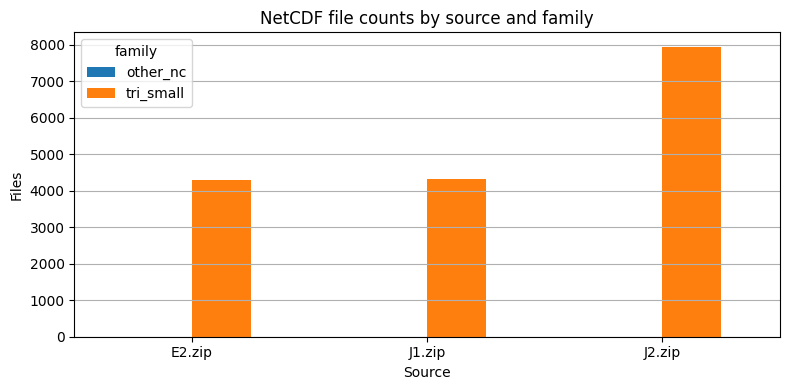

In [8]:
family_counts = inventory_df.groupby(["source_name", "family"]).size().unstack(fill_value=0)
ax = family_counts.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("NetCDF file counts by source and family")
ax.set_xlabel("Source")
ax.set_ylabel("Files")
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_counts_by_source_family.png", dpi=180, bbox_inches="tight")
plt.show()

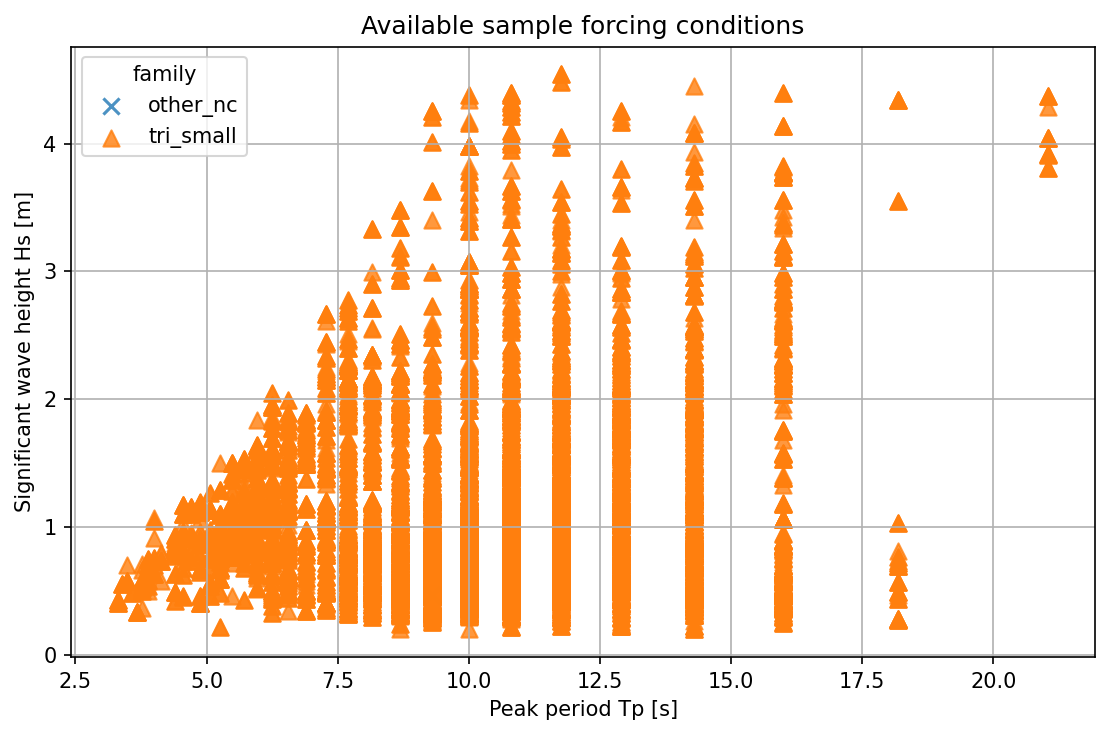

In [9]:
plot_df = inventory_df.dropna(subset=["Hs", "PeakPeriod"]).copy()

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)
markers = {"stats": "o", "tri_full": "s", "tri_small": "^", "other_nc": "x"}
for family, sub in plot_df.groupby("family"):
    ax.scatter(sub["PeakPeriod"], sub["Hs"], label=family, marker=markers.get(family, "o"), s=60, alpha=0.8)

ax.set_title("Available sample forcing conditions")
ax.set_xlabel("Peak period Tp [s]")
ax.set_ylabel("Significant wave height Hs [m]")
ax.grid(True)
ax.legend(title="family")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_hs_tp_scatter.png", dpi=180, bbox_inches="tight")
plt.show()

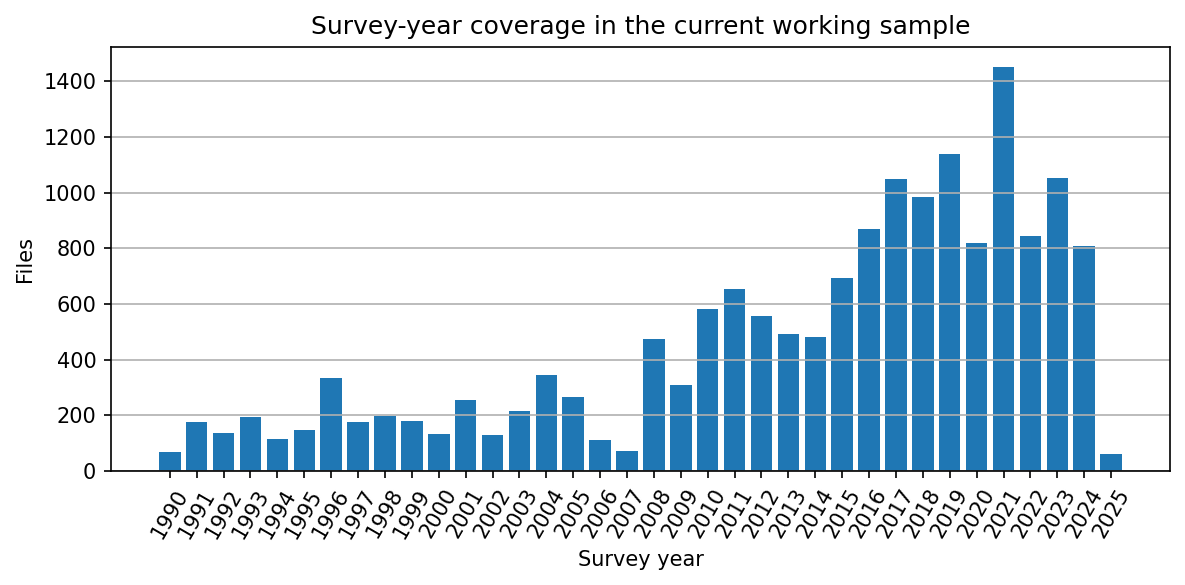

Hs                                 PeakPeriod                   \
           count     min  median    mean     max      count     min   median   
family                                                                         
other_nc       1  0.4667  0.4667  0.4667  0.4667          1  9.3023   9.3023   
tri_small  16548  0.2002  0.8711  1.0742  4.5421      16548  3.3058  10.8108   

                                DX                                TOTAL_TIME  \
              mean      max  count     min  median    mean    max      count   
family                                                                         
other_nc    9.3023   9.3023      1  1.1040  1.1040  1.1040  1.104          1   
tri_small  10.5868  21.0526  16548  0.2424  1.3051  1.2715  2.632      16548   

                                                      t_prop            \
                 min     median       mean        max  count       min   
family                                                                   
other_nc   1255.4417  1255.4417  1255.4417  1255.4417      1  156.9302   
tri_small  1006.8702  1248.6319  1266.0098  2350.6860  16548  125.8588   

                                         
             median      mean       max  
family                                   
other_nc   156.9302  156.9302  156.9302  
tri_small  156.0790  158.2512  293.8357

In [10]:
date_df = inventory_df.dropna(subset=["ba_date"]).copy()
if not date_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    year_counts = date_df["ba_date"].dt.year.value_counts().sort_index()
    ax.bar(year_counts.index.astype(str), year_counts.values)
    ax.set_title("Survey-year coverage in the current working sample")
    ax.set_xlabel("Survey year")
    ax.set_ylabel("Files")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(True, axis="y")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_survey_year_counts.png", dpi=180, bbox_inches="tight")
    plt.show()

numeric_summary = (
    inventory_df.groupby("family")[["Hs", "PeakPeriod", "DX", "TOTAL_TIME", "t_prop"]]
    .agg(["count", "min", "median", "mean", "max"])
    .round(4)
)
numeric_summary.to_csv(OUTPUT_DIR / "family_numeric_summary.csv")
display(numeric_summary)

## 4. Raw time-series branch (`tri_full` + `tri_small`)
The raw files are processed one file at a time and reduced to standardized centerline summaries.  
This is the branch you will use when you want reproducible hydrodynamic EDA without keeping the full native time series in memory.

In [13]:
raw_files = [(src, path) for src, path in nc_files if inventory_df.loc[inventory_df["relative_path"] == str(path), "family"].iloc[0] in ("tri_full", "tri_small")]
print(f"raw files: {len(raw_files)}")

def select_centerline(arr, y_index=ANALYSIS_Y_INDEX):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2:
        if arr.shape[1] <= 5 and arr.shape[0] > arr.shape[1]:
            return arr[:, min(y_index, arr.shape[1] - 1)]
        return arr
    if arr.ndim == 3:
        axis = int(np.argmin(arr.shape))
        if arr.shape[axis] <= 5:
            return np.take(arr, indices=min(y_index, arr.shape[axis] - 1), axis=axis)
    raise ValueError(f"Cannot infer centerline axis from shape {arr.shape}")

def ensure_time_first(arr, x_len):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    if arr.shape[-1] == x_len:
        return arr.reshape(-1, x_len)
    if arr.shape[0] == x_len:
        return np.moveaxis(arr, 0, -1).reshape(-1, x_len)
    raise ValueError(f"Cannot align array of shape {arr.shape} to x_len={x_len}")

def process_raw_file(path: Path, source_name: str):
    with open_ds(path) as ds:
        attrs = {k: scalarize(v) for k, v in ds.attrs.items()}
        family = infer_family_from_vars(ds.data_vars)

        x = ds["X"].values.astype(float)
        z = select_centerline(ds["Z"].values.astype(float))
        eta = ensure_time_first(select_centerline(ds["eta"].values.astype(float)), len(x))
        mask = ensure_time_first(select_centerline(ds["mask"].values.astype(float)), len(x))
        nubrk = ensure_time_first(select_centerline(ds["nubrk"].values.astype(float)), len(x))

        t = ds["t_FW"].values.astype(float) if "t_FW" in ds.coords else np.arange(eta.shape[0], dtype=float)
        start_idx = 0
        if pd.notna(attrs.get("t_prop")):
            start_idx = int(np.searchsorted(t, float(attrs.get("t_prop"))))

        eta_use = eta[start_idx:]
        mask_use = mask[start_idx:]
        nubrk_use = nubrk[start_idx:]

        wet_fraction = np.nanmean(mask_use > 0.5, axis=0)
        breaking_fraction = np.nanmean(nubrk_use > 0, axis=0)
        eta_abs_mean = np.nanmean(np.abs(eta_use), axis=0)

        extra_curves = {}
        if "U_undertow" in ds.data_vars:
            undertow = ensure_time_first(select_centerline(ds["U_undertow"].values.astype(float)), len(x))
            extra_curves["undertow_mean"] = np.nanmean(undertow[start_idx:], axis=0)
        if "roller" in ds.data_vars:
            roller = ensure_time_first(select_centerline(ds["roller"].values.astype(float)), len(x))
            extra_curves["roller_mean"] = np.nanmean(roller[start_idx:], axis=0)

        raw_curve = pd.DataFrame(
            {
                "x": x,
                "z": z,
                "wet_fraction": wet_fraction,
                "breaking_fraction": breaking_fraction,
                "eta_abs_mean": eta_abs_mean,
            }
        )
        for key, values in extra_curves.items():
            raw_curve[key] = values

        wet_mask = raw_curve["wet_fraction"] > 0
        wet_domain = raw_curve.loc[wet_mask].copy()
        if wet_domain.empty:
            wet_domain = raw_curve.copy()

        x0 = float(wet_domain["x"].min())
        x1 = float(wet_domain["x"].max())
        norm_grid = np.linspace(0.0, 1.0, NORM_GRID_SIZE)
        wet_domain["x_norm"] = 0.0 if x1 == x0 else (wet_domain["x"] - x0) / (x1 - x0)

        interp_cols = ["z", "wet_fraction", "breaking_fraction", "eta_abs_mean"]
        for maybe_col in ["undertow_mean", "roller_mean"]:
            if maybe_col in wet_domain.columns:
                interp_cols.append(maybe_col)

        interp_payload = {}
        for col in interp_cols:
            interp_payload[col] = np.interp(norm_grid, wet_domain["x_norm"], wet_domain[col])

        norm_profile = pd.DataFrame(
            {
                "source_name": source_name,
                "file": path.name,
                "family": family,
                "x_norm": norm_grid,
                **interp_payload,
            }
        )

        row = {
            "source_name": source_name,
            "file": path.name,
            "family": family,
            "combo_num": attrs.get("COMBO_NUM"),
            "iter": attrs.get("ITER"),
            "surveyNumber": attrs.get("surveyNumber"),
            "profileNumber": attrs.get("profileNumber"),
            "ba_date_str": attrs.get("ba_date_str"),
            "sp_date_str": attrs.get("sp_date_str"),
            "Hs": attrs.get("Hs"),
            "PeakPeriod": attrs.get("PeakPeriod"),
            "DX": attrs.get("DX"),
            "TOTAL_TIME": attrs.get("TOTAL_TIME"),
            "t_prop": attrs.get("t_prop"),
            "x_min": float(np.nanmin(x)),
            "x_max": float(np.nanmax(x)),
            "z_min": float(np.nanmin(z)),
            "z_max": float(np.nanmax(z)),
            "wet_fraction_mean": float(np.nanmean(wet_fraction)),
            "wet_fraction_min": float(np.nanmin(wet_fraction)),
            "wet_fraction_max": float(np.nanmax(wet_fraction)),
            "breaking_fraction_mean": float(np.nanmean(breaking_fraction)),
            "breaking_fraction_max": float(np.nanmax(breaking_fraction)),
            "eta_abs_mean_mean": float(np.nanmean(eta_abs_mean)),
            "eta_abs_mean_max": float(np.nanmax(eta_abs_mean)),
            "has_undertow": "undertow_mean" in extra_curves,
            "has_roller": "roller_mean" in extra_curves,
        }

        return row, norm_profile, raw_curve, attrs

raw_rows, raw_norm_profiles, raw_examples = [], [], []
for idx, (source_name, path) in enumerate(raw_files, start=1):
    if idx % 50 == 0 or idx == 1 or idx == len(raw_files):
        print(f"Processing raw file {idx:,} / {len(raw_files):,}")
    row, norm_profile, raw_curve, attrs = process_raw_file(path, source_name)
    raw_rows.append(row)
    raw_norm_profiles.append(norm_profile)

    if len(raw_examples) < RAW_EXAMPLE_COUNT:
        raw_examples.append((path.name, raw_curve.copy(), attrs.copy()))

raw_features_df = pd.DataFrame(raw_rows).sort_values(["combo_num", "file"]).reset_index(drop=True)
raw_norm_profiles_df = pd.concat(raw_norm_profiles, ignore_index=True) if raw_norm_profiles else pd.DataFrame()

if EXPORT_PROCESSED_TABLES:
    raw_features_df.to_csv(OUTPUT_DIR / "raw_metadata_features.csv", index=False)
    if EXPORT_LONG_TABLES and not raw_norm_profiles_df.empty:
        raw_norm_profiles_df.to_csv(OUTPUT_DIR / "raw_norm_profiles_long.csv.gz", index=False, compression="gzip")

display(raw_features_df.head())
print(f"\nRaw standardized profiles rows: {len(raw_norm_profiles_df):,}")

raw files: 16548
Processing raw file 1 / 16,548
Processing raw file 50 / 16,548
Processing raw file 100 / 16,548
Processing raw file 150 / 16,548
Processing raw file 200 / 16,548
Processing raw file 250 / 16,548
Processing raw file 300 / 16,548
Processing raw file 350 / 16,548
Processing raw file 400 / 16,548
Processing raw file 450 / 16,548
Processing raw file 500 / 16,548
Processing raw file 550 / 16,548
Processing raw file 600 / 16,548
Processing raw file 650 / 16,548
Processing raw file 700 / 16,548
Processing raw file 750 / 16,548
Processing raw file 800 / 16,548
Processing raw file 850 / 16,548
Processing raw file 900 / 16,548
Processing raw file 950 / 16,548
Processing raw file 1,000 / 16,548
Processing raw file 1,050 / 16,548
Processing raw file 1,100 / 16,548
Processing raw file 1,150 / 16,548
Processing raw file 1,200 / 16,548
Processing raw file 1,250 / 16,548
Processing raw file 1,300 / 16,548
Processing raw file 1,350 / 16,548
Processing raw file 1,400 / 16,548
Processing 

,source_name,file,family,combo_num,iter,surveyNumber,profileNumber,ba_date_str,sp_date_str,Hs,PeakPeriod,DX,TOTAL_TIME,t_prop,x_min,x_max,z_min,z_max,wet_fraction_mean,wet_fraction_min,wet_fraction_max,breaking_fraction_mean,breaking_fraction_max,eta_abs_mean_mean,eta_abs_mean_max,has_undertow,has_roller
0,E2.zip,nc_small_ali_00001.nc,tri_small,1,1,1270.0,274.0,04/17/2023,01/21/2002 06:00,2.9293,10.0000,1.1974,1170.2830,146.2854,0.0,1044.1226,-1.0776,9.2274,0.9957,0.3587,1.0,4.5252e-04,0.0088,0.4741,1.1047,False,False
1,J1.zip,nc_small_ali_00001.nc,tri_small,1,1,1069.0,777.0,02/14/2012,01/21/2002 06:00,1.6285,14.2857,1.7603,1152.8393,144.1049,0.0,1274.4531,-1.0932,9.0488,0.9934,0.1567,1.0,6.6043e-05,0.0119,0.2833,1.1127,False,False
2,J2.zip,nc_small_ali_00001.nc,tri_small,1,1,1128.0,137.0,11/16/2016,01/21/2002 06:00,2.2855,10.0000,1.1974,1245.7344,155.7168,0.0,1077.6494,-2.9586,8.4444,0.9738,0.0000,1.0,1.3381e-04,0.0249,0.4156,2.9086,False,False
3,E2.zip,nc_small_ali_00002.nc,tri_small,2,2,1129.0,960.0,01/05/2017,01/21/2002 06:00,1.0733,10.8108,1.3051,1264.6098,158.0762,0.0,1130.2474,-3.5876,7.8924,0.9653,0.0000,1.0,5.1596e-06,0.0005,0.2461,3.5377,False,False
4,J1.zip,nc_small_ali_00002.nc,tri_small,2,2,1209.0,1052.0,08/23/2021,01/21/2002 06:00,0.9954,10.0000,1.1974,1226.2471,153.2809,0.0,1071.6625,-1.9080,8.5010,0.9708,0.0000,1.0,2.1376e-05,0.0022,0.2190,1.8580,False,False



Raw standardized profiles rows: 3,309,600


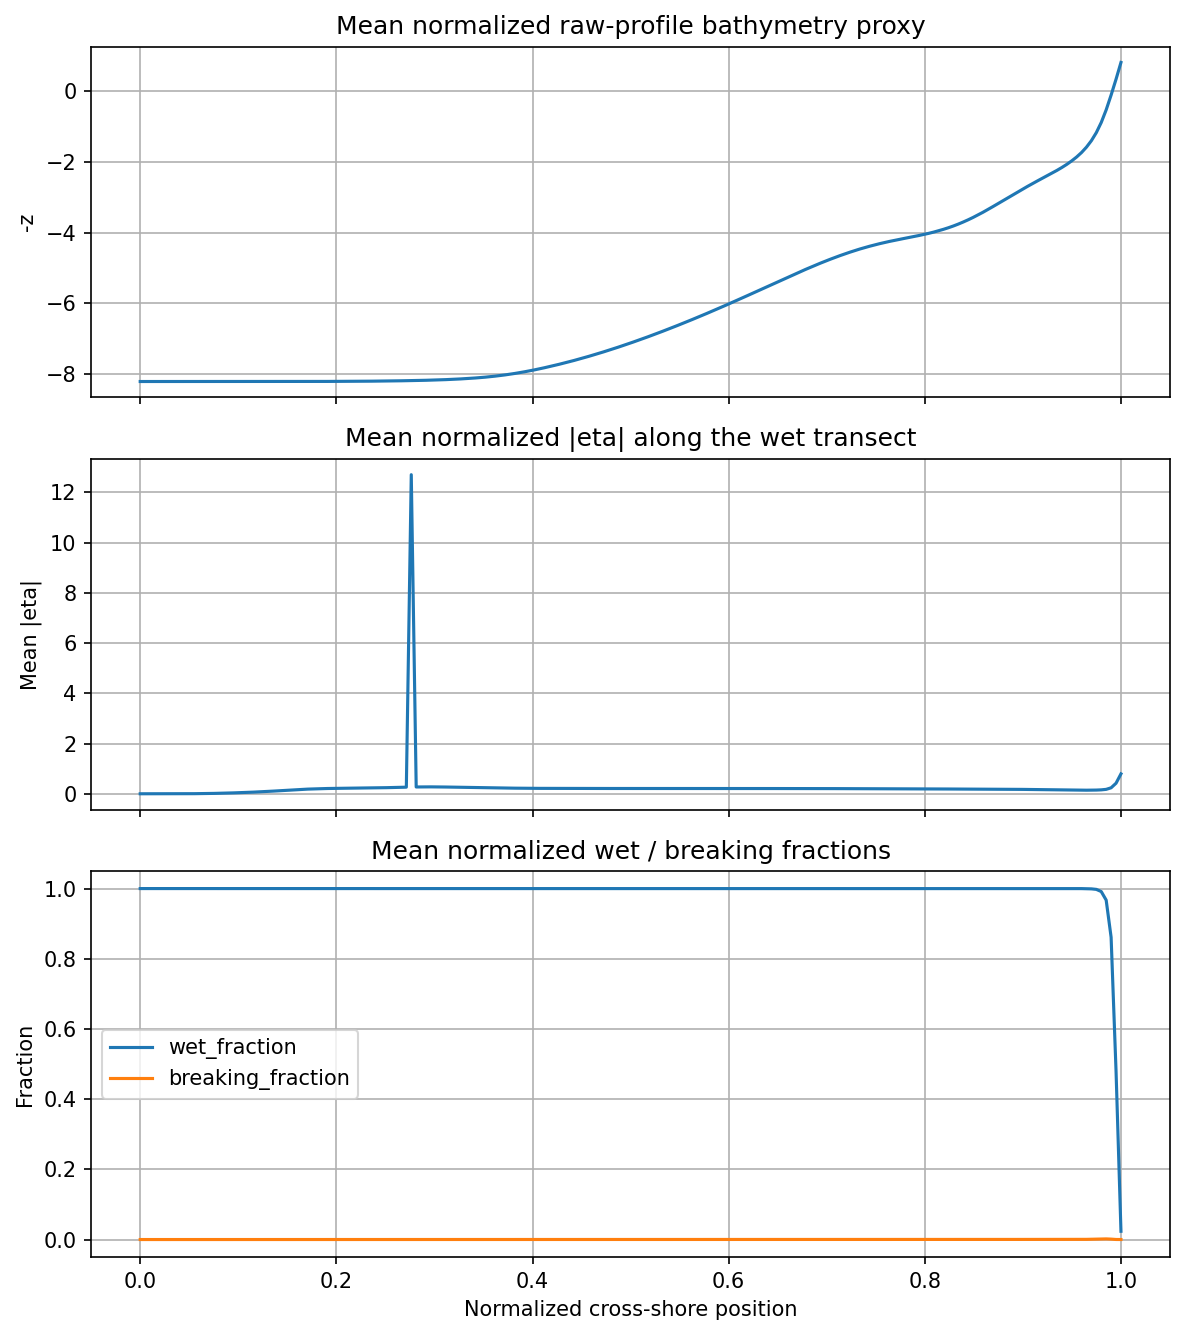

In [14]:
if not raw_norm_profiles_df.empty:
    mean_norm = raw_norm_profiles_df.groupby("x_norm")[["z", "wet_fraction", "breaking_fraction", "eta_abs_mean"]].mean().reset_index()

    fig, axes = plt.subplots(3, 1, figsize=(8, 9), dpi=150, sharex=True, height_ratios=[1.0, 1.0, 1.1])

    axes[0].plot(mean_norm["x_norm"], -mean_norm["z"])
    axes[0].set_title("Mean normalized raw-profile bathymetry proxy")
    axes[0].set_ylabel("-z")
    axes[0].grid(True)

    axes[1].plot(mean_norm["x_norm"], mean_norm["eta_abs_mean"])
    axes[1].set_title("Mean normalized |eta| along the wet transect")
    axes[1].set_ylabel("Mean |eta|")
    axes[1].grid(True)

    axes[2].plot(mean_norm["x_norm"], mean_norm["wet_fraction"], label="wet_fraction")
    axes[2].plot(mean_norm["x_norm"], mean_norm["breaking_fraction"], label="breaking_fraction")
    axes[2].set_title("Mean normalized wet / breaking fractions")
    axes[2].set_xlabel("Normalized cross-shore position")
    axes[2].set_ylabel("Fraction")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_raw_mean_normalized_curves.png", dpi=180, bbox_inches="tight")
    plt.show()

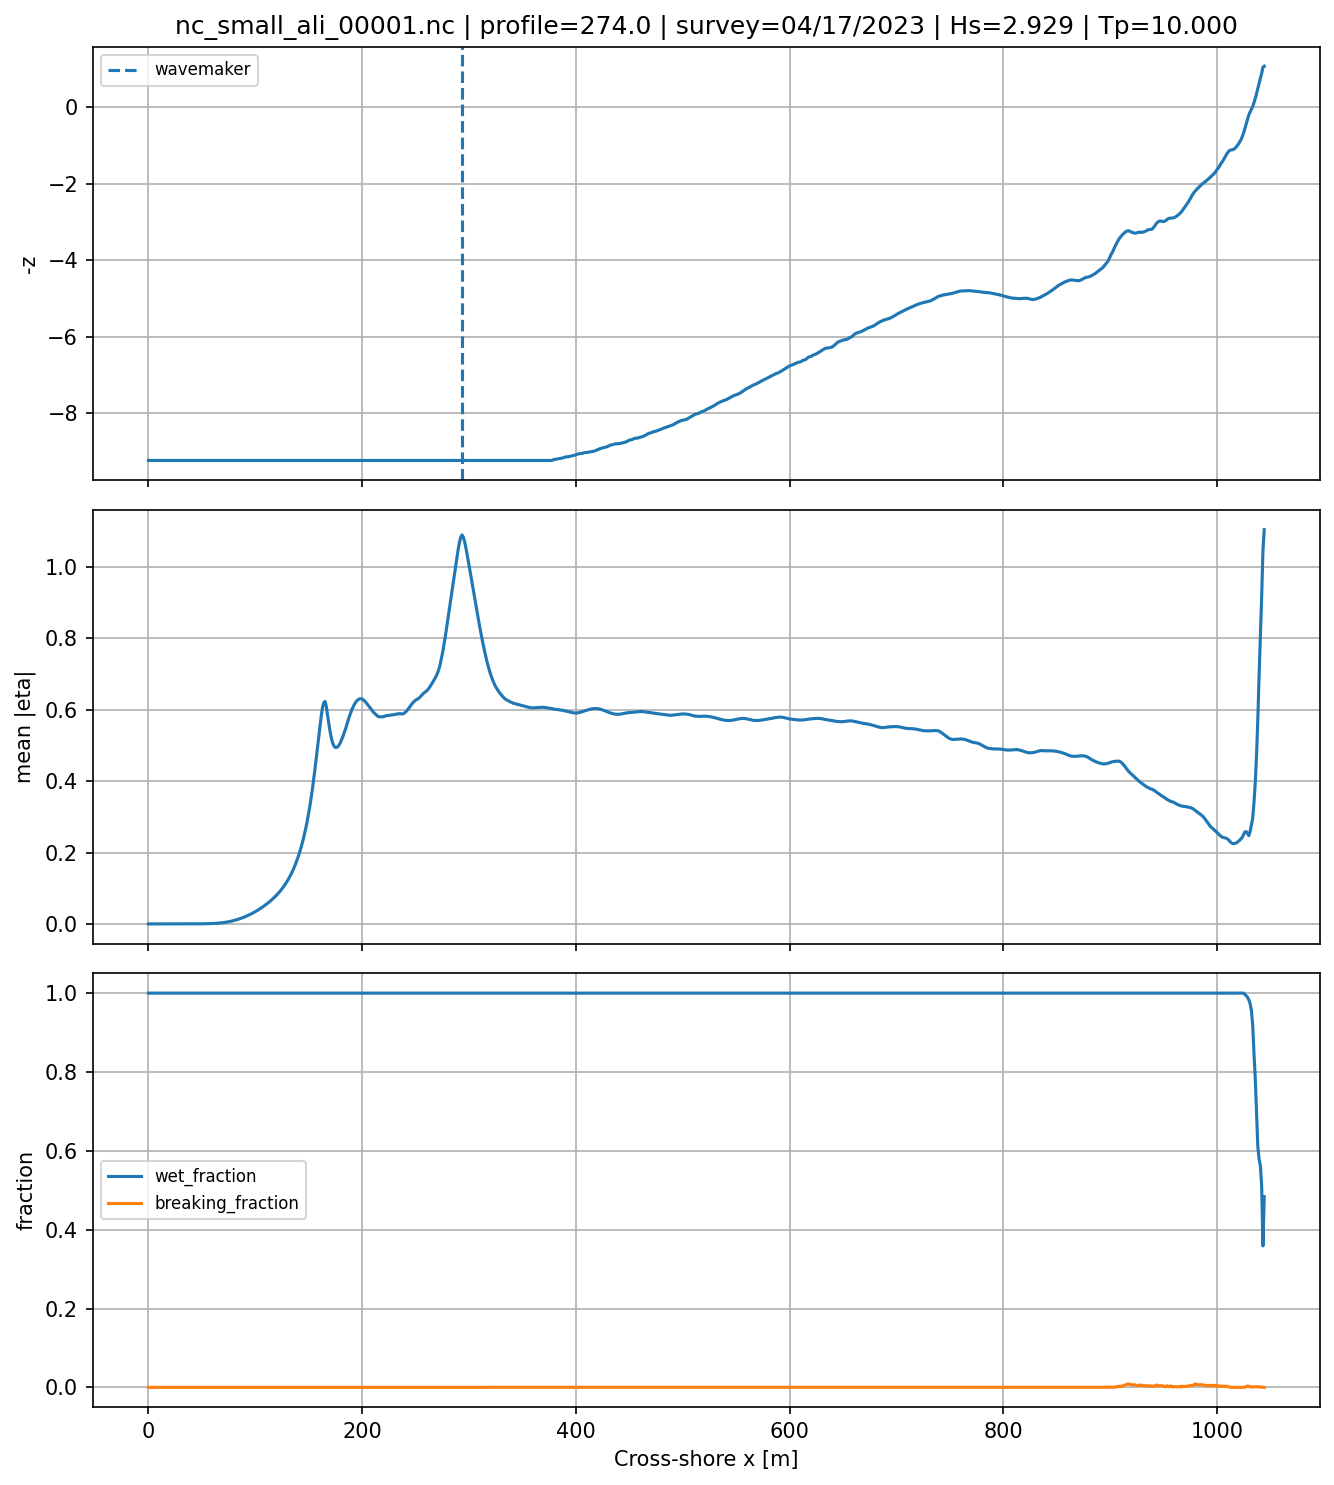

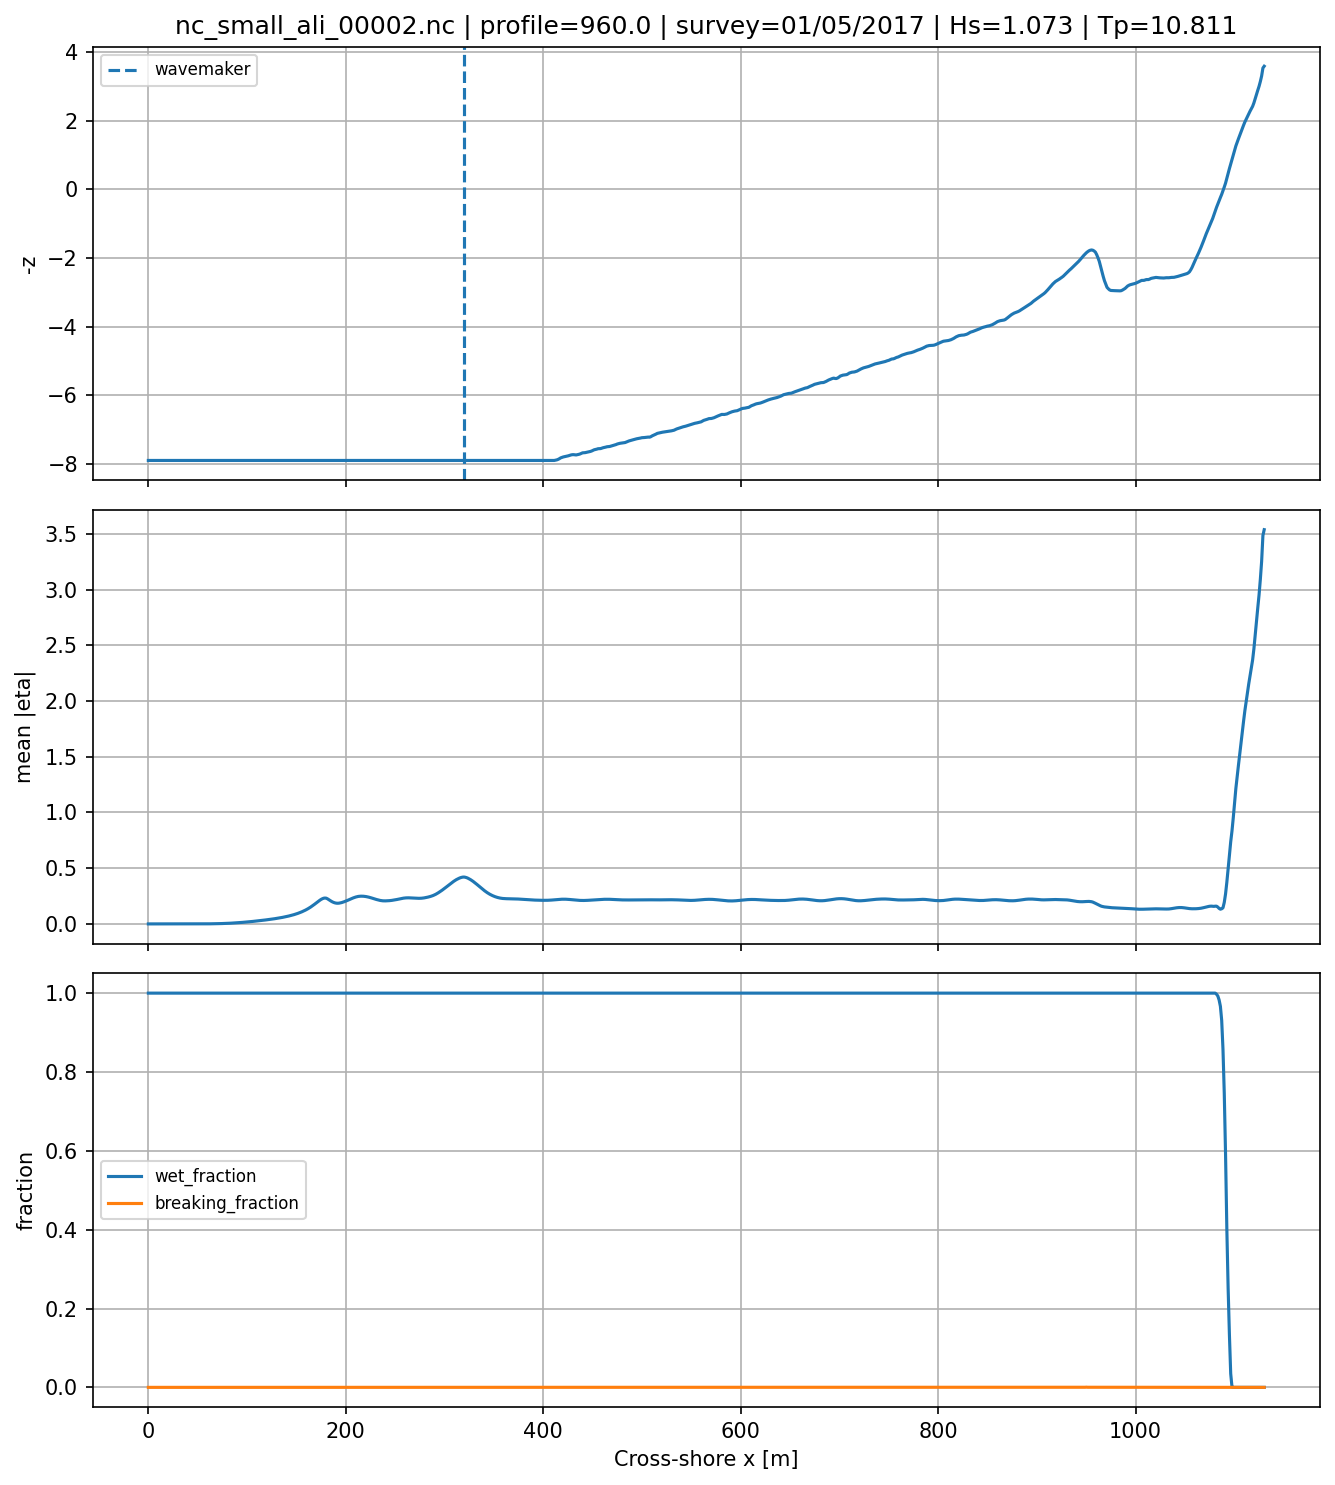

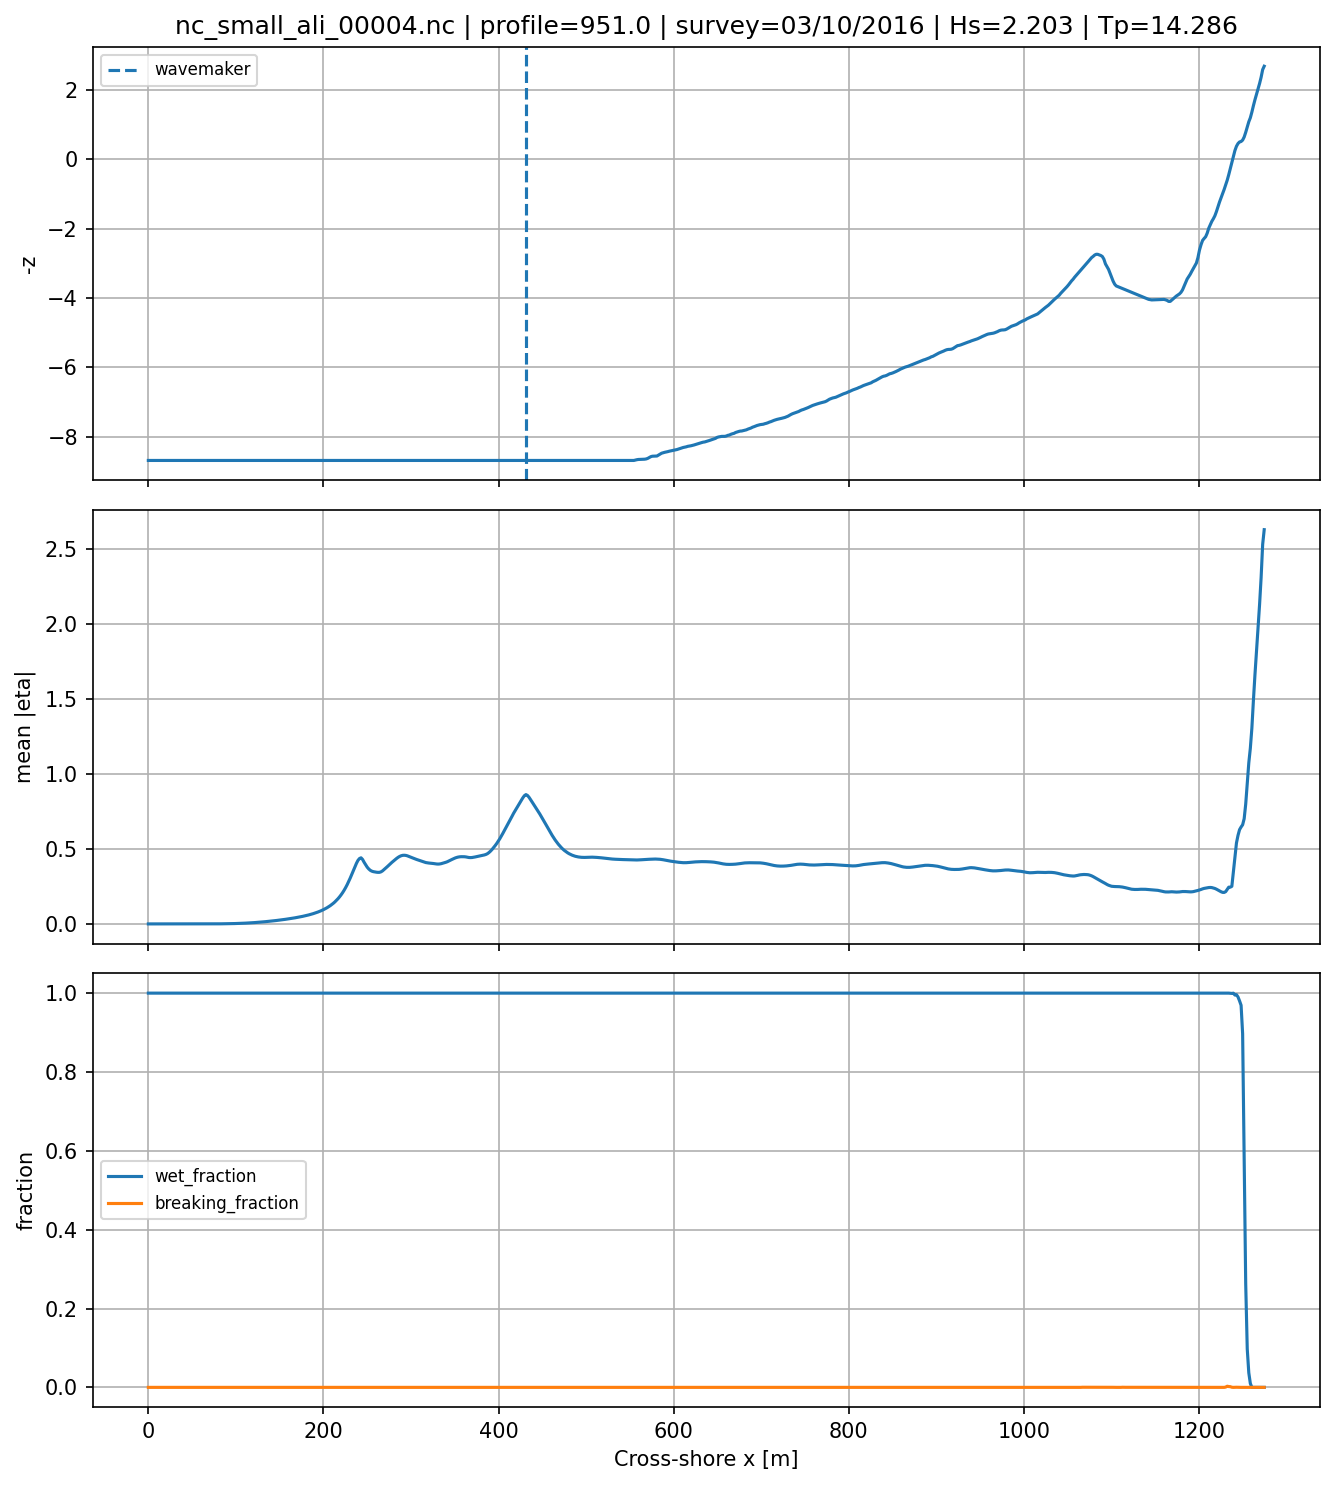

In [15]:
for file_name, curve_df, attrs in raw_examples:
    cols = 2 if {"undertow_mean", "roller_mean"}.issubset(curve_df.columns) else 1
    fig, axes = plt.subplots(3 if cols == 1 else 4, 1, figsize=(9, 10 if cols == 1 else 12), dpi=150, sharex=True)
    axes = np.atleast_1d(axes)

    axes[0].plot(curve_df["x"], -curve_df["z"])
    if pd.notna(attrs.get("Xc_WK")):
        axes[0].axvline(float(attrs.get("Xc_WK")), linestyle="--", label="wavemaker")
        axes[0].legend(fontsize=8)
    axes[0].set_title(
        f"{file_name} | profile={attrs.get('profileNumber')} | survey={attrs.get('ba_date_str')} | "
        f"Hs={attrs.get('Hs'):.3f} | Tp={attrs.get('PeakPeriod'):.3f}"
    )
    axes[0].set_ylabel("-z")
    axes[0].grid(True)

    axes[1].plot(curve_df["x"], curve_df["eta_abs_mean"])
    axes[1].set_ylabel("mean |eta|")
    axes[1].grid(True)

    axes[2].plot(curve_df["x"], curve_df["wet_fraction"], label="wet_fraction")
    axes[2].plot(curve_df["x"], curve_df["breaking_fraction"], label="breaking_fraction")
    axes[2].set_ylabel("fraction")
    axes[2].grid(True)
    axes[2].legend(fontsize=8)

    ax_idx = 3
    if "undertow_mean" in curve_df.columns:
        axes[ax_idx].plot(curve_df["x"], curve_df["undertow_mean"], label="undertow_mean")
        if "roller_mean" in curve_df.columns:
            axes[ax_idx].plot(curve_df["x"], curve_df["roller_mean"], label="roller_mean")
        axes[ax_idx].set_ylabel("extra mean")
        axes[ax_idx].grid(True)
        axes[ax_idx].legend(fontsize=8)
        axes[ax_idx].set_xlabel("Cross-shore x [m]")
    else:
        axes[2].set_xlabel("Cross-shore x [m]")

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"example_{file_name.replace('.nc','')}_overview.png", dpi=180, bbox_inches="tight")
    plt.show()

## 5. Spectral table and processing manifest
This final block creates compact outputs that can be used directly in the write-up and downstream feature engineering.

In [16]:
def extract_spectra_long(path: Path, source_name: str):
    with open_ds(path) as ds:
        attrs = {k: scalarize(v) for k, v in ds.attrs.items()}
        return pd.DataFrame(
            {
                "source_name": source_name,
                "file": path.name,
                "family": infer_family_from_vars(ds.data_vars),
                "combo_num": attrs.get("COMBO_NUM"),
                "profileNumber": attrs.get("profileNumber"),
                "surveyNumber": attrs.get("surveyNumber"),
                "Hs": attrs.get("Hs"),
                "PeakPeriod": attrs.get("PeakPeriod"),
                "period": ds["period"].values.astype(float),
                "amp": ds["amp"].values.astype(float),
                "phase": ds["phase"].values.astype(float),
            }
        )

spectra_frames = [extract_spectra_long(path, source_name) for source_name, path in nc_files]
spectra_df = pd.concat(spectra_frames, ignore_index=True) if spectra_frames else pd.DataFrame()

if EXPORT_PROCESSED_TABLES and not spectra_df.empty:
    spectra_df.to_csv(OUTPUT_DIR / "spectra_long.csv.gz", index=False, compression="gzip")

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "root": str(ROOT),
    "sources": [str(p) for p in sources],
    "materialized_sources": [{**item, "path": str(item["path"])} for item in materialized],
    "netcdf_file_count": len(nc_files),
    "family_counts": inventory_df["family"].value_counts(dropna=False).to_dict(),
    "generated_outputs": sorted([p.name for p in OUTPUT_DIR.glob("*") if p.is_file()]),
    "notes": [
        "stats branch kept separate from raw branch",
        "raw branch supports both tri_full and tri_small schema variants",
        "negative profileNumber can be valid in Duck FRF coordinates",
        "Z_orig is treated as advisory only because the sample provider notes a likely typo there",
        "raw files are reduced to standardized centerline summaries for scalable first-pass processing",
    ],
}
with open(OUTPUT_DIR / "processing_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Generated files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

print("\nSpectra head")
display(spectra_df.head())

Generated files:
 - family_numeric_summary.csv
 - figures
 - file_inventory.csv
 - processing_manifest.json
 - qa_findings.csv
 - raw_metadata_features.csv
 - raw_norm_profiles_long.csv.gz
 - schema_summary.csv
 - spectra_long.csv.gz

Spectra head


,source_name,file,family,combo_num,profileNumber,surveyNumber,Hs,PeakPeriod,period,amp,phase
0,E2.zip,nc_small_ali_00001.nc,tri_small,1,274.0,1270.0,2.9293,10.0,25.0000,0.0423,2.1300
1,E2.zip,nc_small_ali_00001.nc,tri_small,1,274.0,1270.0,2.9293,10.0,21.0526,0.0371,-0.5273
2,E2.zip,nc_small_ali_00001.nc,tri_small,1,274.0,1270.0,2.9293,10.0,18.1818,0.0361,-1.6895
3,E2.zip,nc_small_ali_00001.nc,tri_small,1,274.0,1270.0,2.9293,10.0,16.0000,0.0408,0.9991
4,E2.zip,nc_small_ali_00001.nc,tri_small,1,274.0,1270.0,2.9293,10.0,14.2857,0.0798,-2.6648


## Suggested report language

You can adapt this directly into the revised write-up:

> The current working sample is now sufficient to document the actual structure of the FUNWAVE-TVD corpus used in this capstone. The sample includes reduced-statistics files standardized to 200 cross-shore points and two raw time-series schema variants, one richer `tri_full` form and one lighter `tri_small` form. A reproducible notebook was created to inventory the files, audit schema consistency, summarize forcing and profile metadata, and convert the raw files into standardized centerline hydrodynamic summaries for downstream modeling. The notebook is designed so the same workflow can be run on the full repository of approximately 20,000 simulations with only a configuration change to the source paths.